In [47]:
import missionbio.mosaic
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sclib.mission
import sclib.confusion
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats
import distinctipy
import palettable

In [50]:
sc = missionbio.mosaic.load("../data/cell_line_mix_obj_1/cell_line_mix_obj_1.h5")


Loading, ../data/cell_line_mix_obj_1/cell_line_mix_obj_1.h5
Loaded in 0.1s.


In [51]:
sc.dna.add_col_attr(name="id", value=np.array([x.split(" ")[1] for x in sc.dna.ids()]))


In [52]:
sc.cnv.get_gene_names()


Fetching annotation for amplicons.
Added gene names to the "gene_name" column attribute


## First just filter out poor RNA


In [53]:
sc.protein = sc.protein[sc.dna.barcodes(), :]
rna_ids = np.array(
    [
        "COL1A2",
        "JAG1",
        "KRT5",
        "NOTCH3",
        "COL17A1",
        "KRT14",
        "VWF",
        "CD14",
        "CD3E",
        "HES5",
        "BIRC5",
        "HEY1",
        "TOP2A",
        "ITGA6",
        "PTCH1",
        "SPRR3",
        "GLI1",
        "HES7",
        "TP53",
        "KRT23",
        "KLF5",
        "ITGA4",
        "CDH1",
        "S100A8",
        "ITGB4",
        "TP63",
        "CD34",
        "JAG2",
        "KRT4",
        "KRT13",
        "KRT15",
        "EPCAM",
        "MKI67",
        "NGFR",
        "S100A9",
        "SOX2",
        "VIM",
        "LY6D",
        "KLF4",
        "GLI2",
        "HES1",
        "IVL",
        "KRT7",
        "DLL1",
        "SMO",
        "HEY2",
        "HEYL",
        "MAML1",
        "GTSE1",
        "NOTCH1",
        "MAML3",
        "DLL4",
        "DLK2",
        "WNT10A",
        "WNT4",
        "WNT5B",
        "MAML2",
        "ITGB1",
        "WNT7B",
        "PTPRC",
        "DCN",
        "CLEC14A",
        "RBPJ",
        "RBPJ",
        "DLL3",
        "UBE2C",
        "CD24",
    ]
)
sc.protein.col_attrs["id"] = rna_ids
sc.protein = sc.protein.drop("RBPJ")
sc.protein = sc.protein[
    sc.protein.barcodes(),
    list(
        sc.protein.get_attribute(attribute="read_counts", constraint="row+col")
        .loc[
            :,
            (
                sc.protein.get_attribute(
                    attribute="read_counts", constraint="row+col"
                ).sum()
                > 15000
            ),
        ]
        .columns
    ),
]
sc.protein.normalize_reads()
sc.protein.run_umap(attribute="normalized_counts")


## Prep DNA

Filtering consecutive and anntating data


In [54]:
variants = sc.dna.get_annotations()
variants = variants[variants["Position"] != ""]
ngt_matrix = sc.dna.get_attribute(attribute="NGT", constraint="row+col")
NGT_dict = {0: "WT", 1: "HET", 2: "HOM", 3: "MISSING"}
ngt_ann_matrix = ngt_matrix.apply(lambda x: pd.Series.map(x, NGT_dict))
variants_w_counts = variants.join(
    ngt_ann_matrix.T.apply(lambda x: x[x != "MISSING"].value_counts(), axis=1).fillna(0)
)


In [55]:
sc.dna.filter_variants()
sc.dna = sc.dna[sc.dna.filter_barcodes(completeness=70), :]
sc.protein = sc.protein[sc.dna.filter_barcodes(completeness=70), :]

In [56]:
sc.heatmap(clusterby="dna", sortby="protein", drop="cnv", flatten=False)


In [59]:
sc.dna.plot_variant_correlation()


In [60]:
var_binary_dict = {0: 0, 1: 1, 2: 1, 3: 0}
corr_frame_pt = pd.DataFrame(index=sc.protein.ids())
for var in sc.dna.ids():
    corr_dict = {}
    for col_name, col_data in sc.protein.get_attribute(
        attribute="normalized_counts", constraint="row+col"
    )[
        sc.dna.get_attribute(attribute="NGT", constraint="row+col")[var] != 3
    ].iteritems():
        corr_dict[col_name] = (
            stats.pointbiserialr(
                sc.dna.get_attribute(attribute="NGT", constraint="row+col")[var][
                    sc.dna.get_attribute(attribute="NGT", constraint="row+col")[var]
                    != 3
                ].map(var_binary_dict),
                col_data,
            )
        )[0]
    corr_frame_pt[var] = pd.DataFrame(corr_dict.values(), index=corr_dict.keys())
corr_frame_pt = corr_frame_pt.dropna(axis=1)


c:\Users\johnz\anaconda3\envs\mosaic\lib\site-packages\scipy\stats\stats.py:4023: PearsonRConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



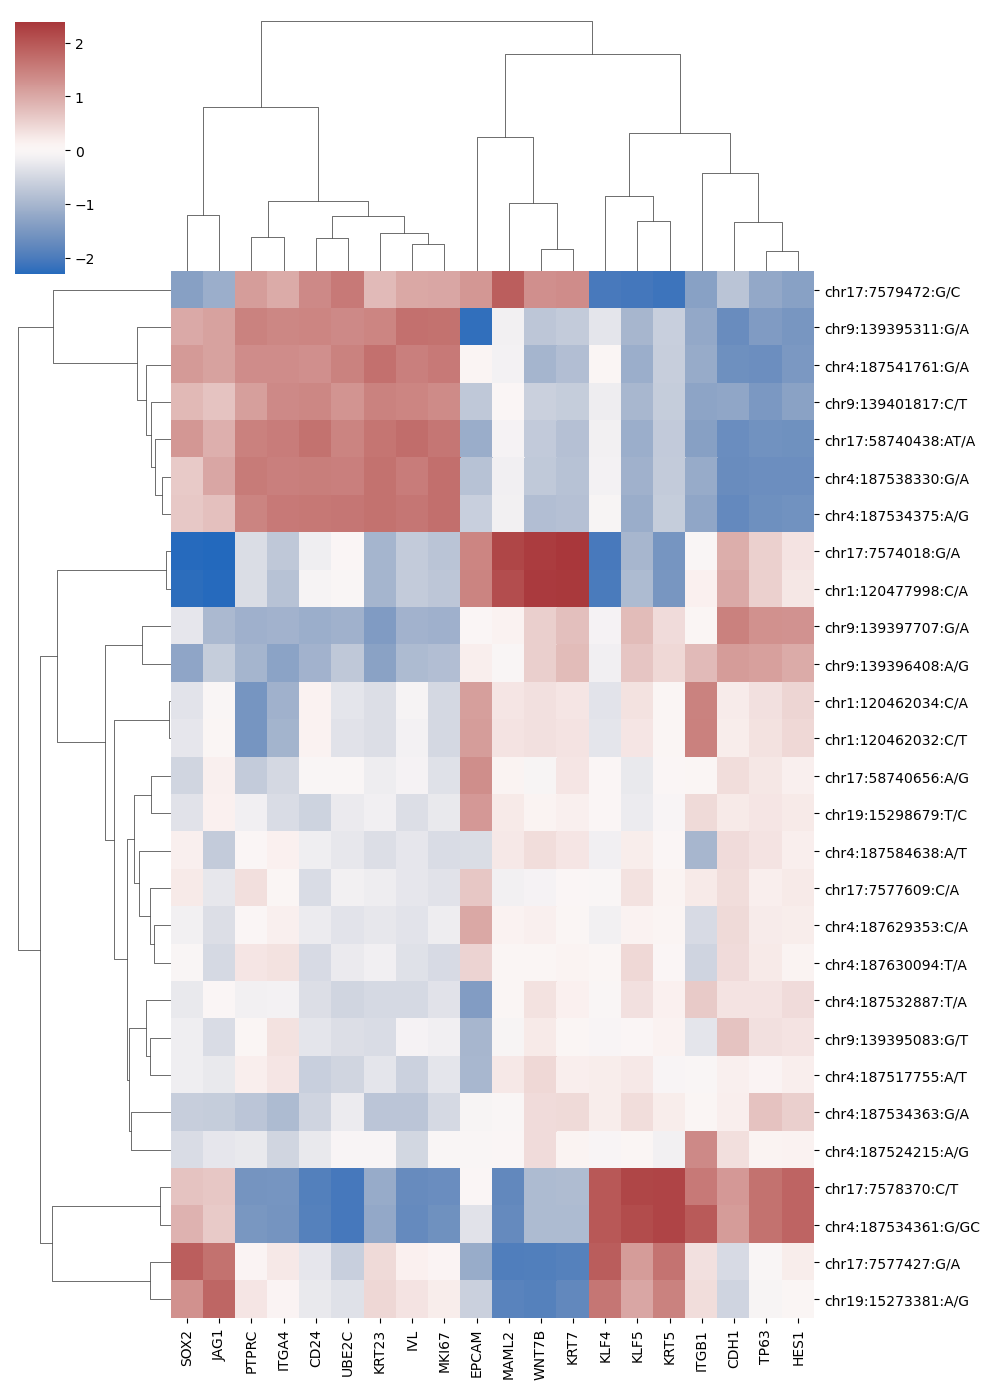

In [61]:
sns.clustermap(corr_frame_pt.T, cmap="vlag", z_score=1, figsize=(10, 14))


In [62]:
sc.dna.heatmap("NGT")


FigureWidget({
    'data': [{'colorscale': [[0.0, '#1f77b4'], [0.3333333333333333, '#1f77b4'],
               …

In [63]:
wes_list = [
    'chr9:139401817:C/T',
    'chr17:58740438:AT/A',
    'chr17:7574018:G/A',
    'chr4:187534361:G/GC',
    'chr17:7578370:C/T',

]

In [64]:
sc.dna = sc.dna.drop(wes_list)

In [65]:
sc.dna.find_clones(similarity=0.9)


Unique clusters found - 4
Clusters after removing missing data - 3


c:\Users\johnz\anaconda3\envs\mosaic\lib\site-packages\missionbio\mosaic\dna.py:117: UserWarning:

Using the "umap" that is already present in the row attributes.



In [66]:
sc.dna.heatmap('NGT')

FigureWidget({
    'data': [{'colorscale': [[0.0, '#1f77b4'], [0.3333333333333333, '#1f77b4'],
               …

In [67]:
sc.protein.scatterplot("umap", colorby="label")


FigureWidget({
    'data': [{'customdata': array([['label: 1<br>AACAACCTAAAGGATCGT-1'],
                      …

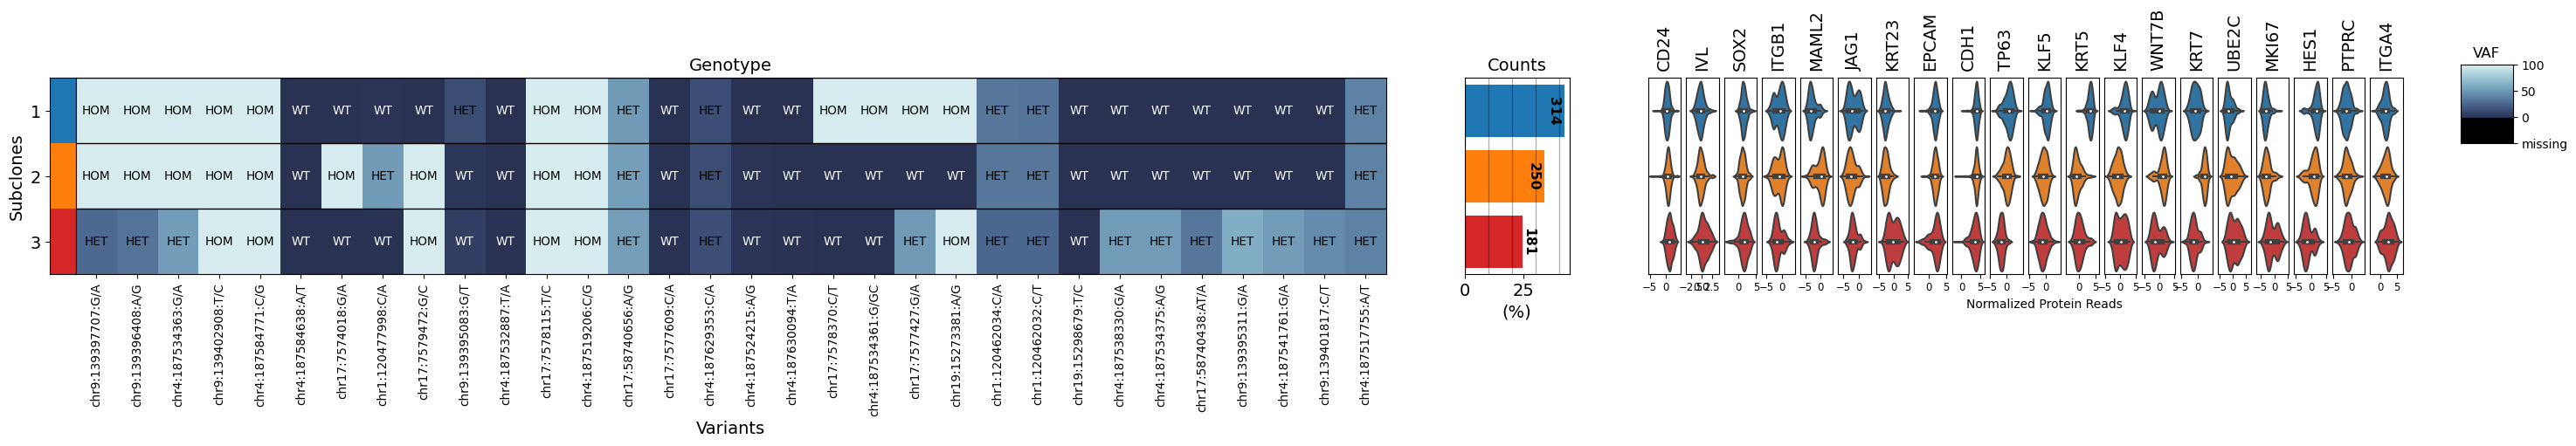

In [68]:
sc.clone_vs_analyte("protein", plot_width=30)


In [69]:
sc.protein.scatterplot(
    "umap",
    features=list(
        sc.protein.get_attribute(attribute="normalized_counts", constraint="row+col")
        .var()
        .sort_values(ascending=False)
        .head(9)
        .index
    ),
    colorby="normalized_counts",
)


In [70]:
sc.dna.scatterplot(
    np.array(sc.protein.get_attribute(attribute="umap")),
    features=list(
        sc.dna.get_attribute(attribute="NGT", constraint="row+col")
        .var()
        .sort_values(ascending=False)
        .head(9)
        .index
    ),
    colorby="NGT",
)


# Labeling on DNA

- chr17:7578370:C/T HOM chr4:187534361:G/GC HOM are KYSE270 markers
- chr17:7574018:G/A HOM is KYSE410 marker
- chr9:139401817:C/T HET and chr9:139395311:G/A HET are HCT116 markers


In [71]:
sc.dna.cluster(attribute="umap", method="kmeans", n_clusters=3)


In [72]:
sc.dna.heatmap("NGT")


FigureWidget({
    'data': [{'colorscale': [[0.0, '#1f77b4'], [0.3333333333333333, '#1f77b4'],
               …

In [73]:
sc.dna.rename_labels({"1": "KYSE270", "2": "KYSE410", "3": "HCT116"})


In [74]:
sc.dna.heatmap("NGT")

FigureWidget({
    'data': [{'colorscale': [[0.0, '#d62728'], [0.3333333333333333, '#d62728'],
               …

In [75]:
list(sc.dna.ids())

['chr9:139397707:G/A',
 'chr9:139396408:A/G',
 'chr4:187534363:G/A',
 'chr9:139402908:T/C',
 'chr4:187584771:C/G',
 'chr4:187584638:A/T',
 'chr17:7574018:G/A',
 'chr1:120477998:C/A',
 'chr17:7579472:G/C',
 'chr9:139395083:G/T',
 'chr4:187532887:T/A',
 'chr17:7578115:T/C',
 'chr4:187519206:C/G',
 'chr17:58740656:A/G',
 'chr17:7577609:C/A',
 'chr4:187629353:C/A',
 'chr4:187524215:A/G',
 'chr4:187630094:T/A',
 'chr17:7578370:C/T',
 'chr4:187534361:G/GC',
 'chr17:7577427:G/A',
 'chr19:15273381:A/G',
 'chr1:120462034:C/A',
 'chr1:120462032:C/T',
 'chr19:15298679:T/C',
 'chr4:187538330:G/A',
 'chr4:187534375:A/G',
 'chr17:58740438:AT/A',
 'chr9:139395311:G/A',
 'chr4:187541761:G/A',
 'chr9:139401817:C/T',
 'chr4:187517755:A/T']

In [30]:
sc.protein.scatterplot("umap", colorby=sc.dna.get_labels())


FigureWidget({
    'data': [{'customdata': array([['label: 1<br>AACAACCTAAAGGATCGT-1'],
                      …

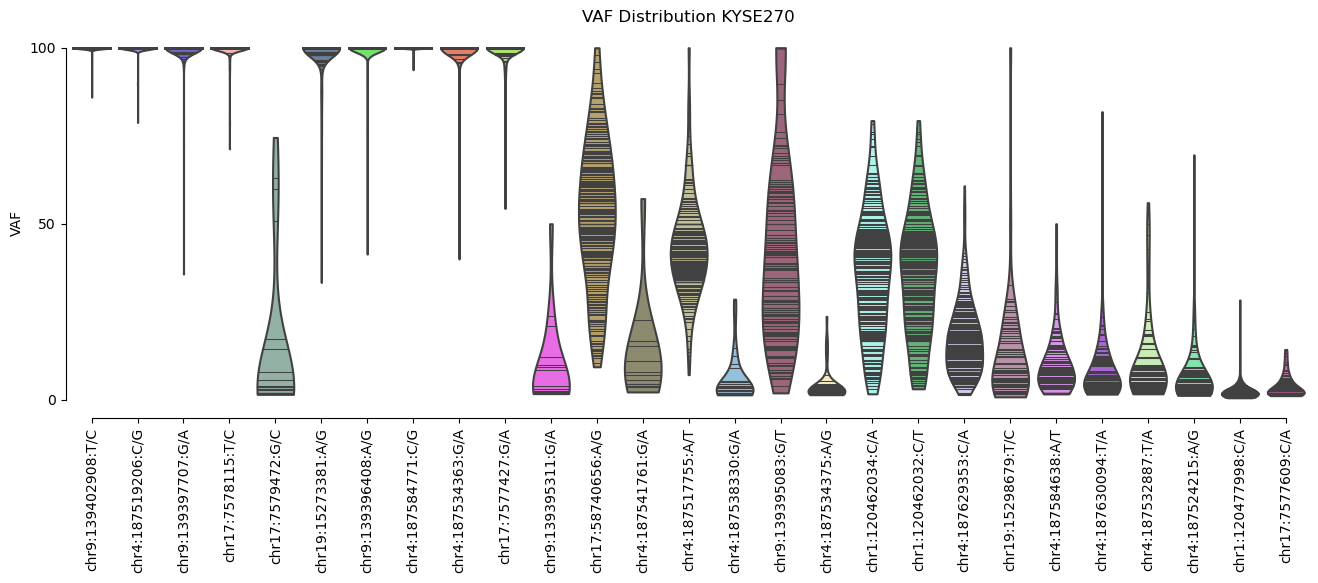

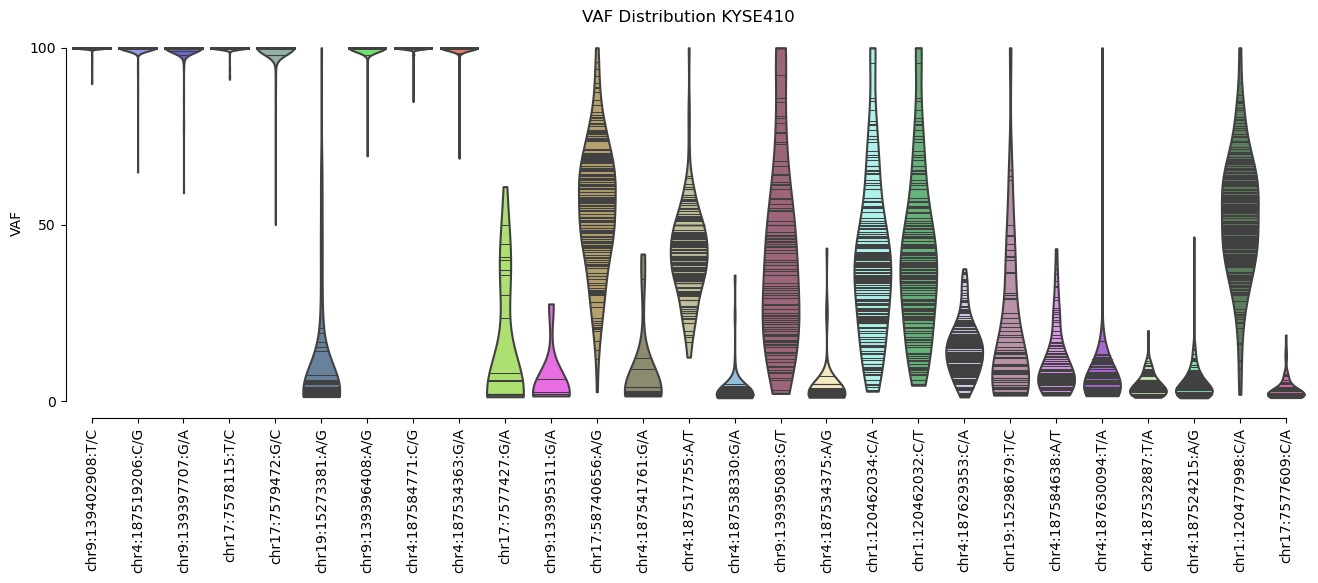

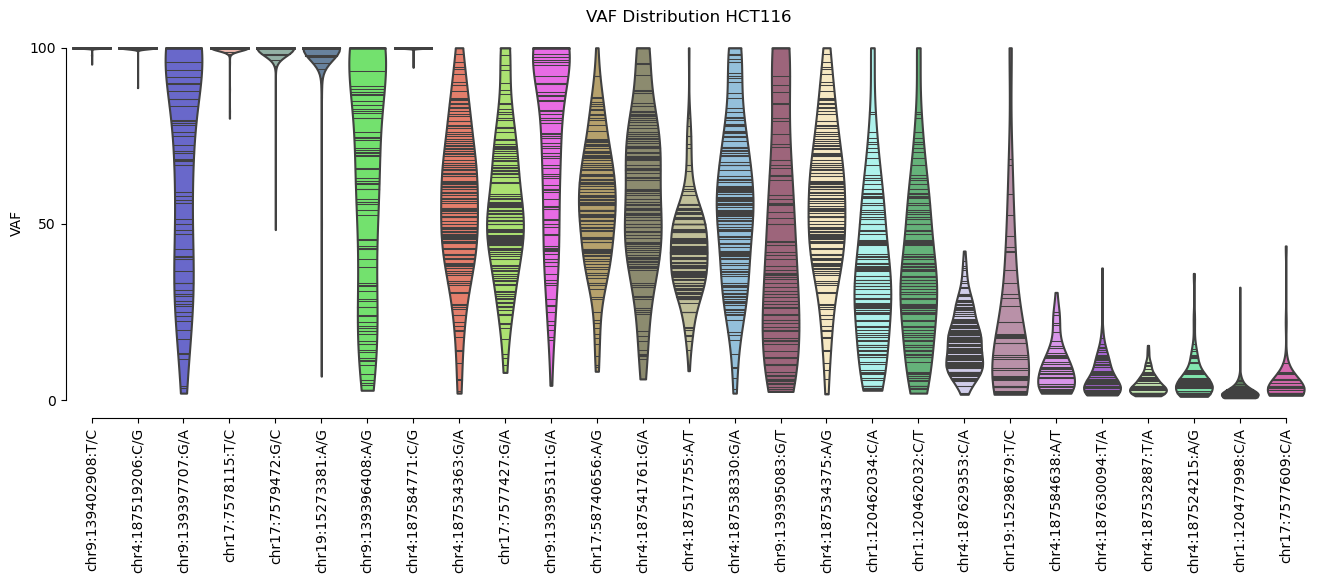

In [31]:
vaf_pal = distinctipy.get_colors(len(sc.dna.ids()), pastel_factor=0.5,n_attempts=1000)
for cell_line in ['KYSE270','KYSE410','HCT116']:
    tmp = sclib.mission.get_mbio_obj_by_label(sc, cell_line)
    plt.figure(figsize=(16,5))
    sns.violinplot(
        tmp.dna.get_attribute('AF', constraint='row+col').replace(0,np.NaN).melt(),
        x='variable',
        y='value',
        hue='variable',
        dodge=False,
        inner='stick',
        bw='silverman',
        cut=0,
        palette=vaf_pal,
        order=sc.dna.get_attribute('AF', constraint='row+col').replace(0,np.NaN).melt().groupby('variable')['value'].median().sort_values(ascending=False).index,
    )
    plt.legend().remove()
    plt.yticks([0,50,100])
    plt.ylabel('VAF')
    plt.xlabel('')
    plt.title('VAF Distribution {}'.format(cell_line))
    sns.despine(offset=2, trim=True)
    plt.xticks(rotation=90)
    #plt.savefig('../mb-paper-figs/supp_figures/fig_s2/ex-{}-va-dist.tiff'.format(cell_line),dpi=300,bbox_inches='tight',transparent=True)

## Labeling on RNA

- KRT5 is KYSE270 marker
- KRT7 is KYSE410 marker
- KRT23 is HCT116 marker


In [32]:
sc.protein.cluster(attribute="umap", method="kmeans", n_clusters=3)


In [33]:
sc.protein.heatmap("normalized_counts")


FigureWidget({
    'data': [{'colorscale': [[0.0, '#1f77b4'], [0.3333333333333333, '#1f77b4'],
               …

In [34]:
sc.protein.rename_labels({"1": "KYSE270", "2": "HCT116", "3": "KYSE410"})


In [35]:
sc.protein.scatterplot("umap", colorby="label")


FigureWidget({
    'data': [{'customdata': array([['label: KYSE270<br>AACAACCTAAAGGATCGT-1'],
                …

In [36]:
label_compare = pd.DataFrame(
    zip(sc.dna.get_labels(), sc.protein.get_labels()),
    index=sc.dna.barcodes(),
    columns=["DNA", "RNA"],
)
label_compare


,DNA,RNA
AACAACCTAAAGGATCGT-1,KYSE270,KYSE270
AACAATGCAAGTCTAAGC-1,KYSE270,KYSE270
AACCATGGTCCAGATCAC-1,KYSE270,KYSE270
AACCGCTGACGTGTATTC-1,KYSE270,KYSE270
AACGATGACCAAGGTGTG-1,HCT116,HCT116
...,...,...
TTGAGCTCTACGGTGTAC-1,HCT116,KYSE410
TTGCTCTGCCCGCAACAC-1,KYSE270,KYSE270
TTGCTCTGCGTACTCTAC-1,KYSE410,KYSE410
TTGTATCACGTCAATACA-1,KYSE270,KYSE270


In [37]:
print(classification_report(label_compare["DNA"], label_compare["RNA"]))


              precision    recall  f1-score   support

      HCT116       0.76      0.97      0.85       181
     KYSE270       0.97      0.92      0.94       314
     KYSE410       0.98      0.85      0.91       250

    accuracy                           0.91       745
   macro avg       0.90      0.91      0.90       745
weighted avg       0.92      0.91      0.91       745



Text(0.5, 23.52222222222222, 'RNA Call\n\nAccuracy: 0.907')

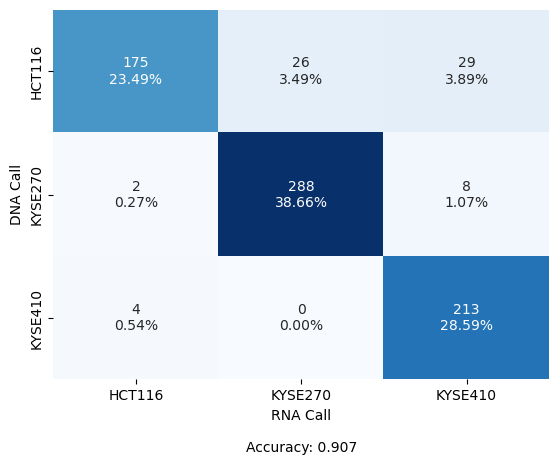

In [38]:
sclib.confusion.make_confusion_matrix(
    cf=confusion_matrix(label_compare["RNA"], label_compare["DNA"]),
    categories=list(np.unique(label_compare["DNA"])),
    cbar=False,
)
plt.ylabel("DNA Call")
#plt.xlabel("RNA Call")
plt.xlabel(
    "RNA Call"
    + "\n\nAccuracy: {:0.3f}".format(
        np.trace(confusion_matrix(label_compare["RNA"], label_compare["DNA"]))
        / float(np.sum(confusion_matrix(label_compare["RNA"], label_compare["DNA"])))
    )
)
# plt.xlabel('RNA Call\n\n' + classification_report(label_compare['RNA'],label_compare['DNA']))


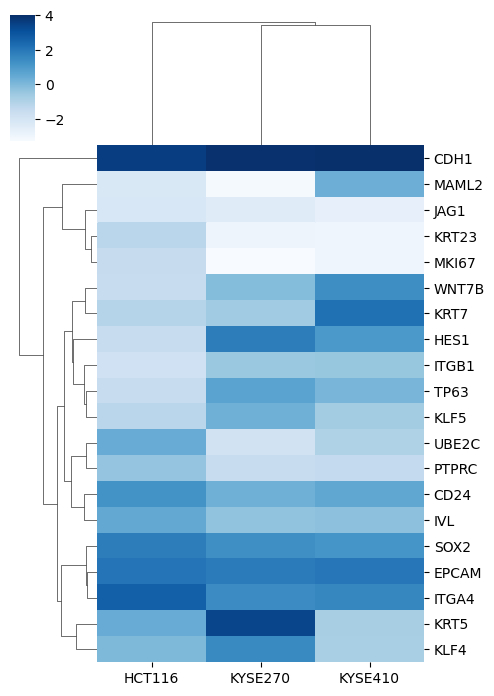

In [39]:
sns.clustermap(
    sc.protein.signature("normalized_counts").T, cmap=sns.color_palette("Blues", as_cmap=True), figsize=(5, 7)
)

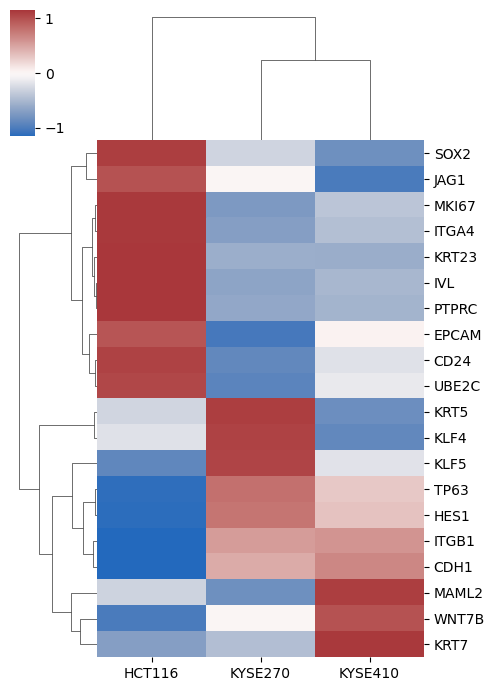

In [40]:
sns.clustermap(
    sc.protein.signature("normalized_counts").T, cmap="vlag", z_score=0, figsize=(5, 7)
)

In [41]:
sc.protein.scatterplot(
    "umap",
    features=["KRT5", "KRT7", "KRT23"],
    colorby="normalized_counts",
)


In [43]:
sc.heatmap(clusterby="dna", sortby="protein", drop="cnv", flatten=False)
